In [16]:
from matplotlib import pyplot as plt
# from brokenaxes import brokenaxes
import numpy as np
import os
import sys
import matplotlib.ticker as mticker
from matplotlib.ticker import FuncFormatter
import matplotlib.ticker as mtick

my_figsize = [10, 8]
my_fontsize = 35
WIDTH = 0.05  # the width of the bars
SHORT = 100001-2 # 100KB
LONG = 1000000 # 1000KB
LOADS = ['0.1', '0.25', '0.5', '0.75', '1']
labels = ['10', '25', '50', '75', '100']

WORKLOADS = ['W5']
METRICS = ['FCT', 'GOODPUT']

os.chdir(sys.path[0])
os.chdir('./')

Algo = [
        "../../zeropod-singlepod/DATA/NSDI25/ost=5/W5/ppt_16_topk_4", 
        "../../zeropod-singlepod/DATA/NSDI25/ost=5/W5/ppt_16_topk_8", 
        "../../zeropod-singlepod/DATA/NSDI25/ost=5/W5/ppt_16_topk_16", 
        "../../zeropod-singlepod/DATA/NSDI25/ost=5/W5/ppt_16_topk_32", 
        ]

SCHEMES = Algo

DATA_DIR_TEMP = '{scheme}/DATA_zeropod_'+ WORKLOADS[0]+ '_{load}/'

FIG_FILE_NAME = WORKLOADS[0]
FIGURE_DIR = '../FIGS/'+ FIG_FILE_NAME +'/GOODPUT/'
if not os.path.exists(FIGURE_DIR):
    os.makedirs(FIGURE_DIR)

data = {}
for scheme in SCHEMES:
    data[scheme] = {}
    for workload in WORKLOADS:
        data[scheme][workload] = {}
        for load in LOADS:
            data[scheme][workload][load] = {}

                    
                
for scheme in SCHEMES:
        for workload in WORKLOADS:
            for load in LOADS:
                dir_path = DATA_DIR_TEMP.format(scheme=scheme, workload=workload, load=load)
                data[scheme][workload][load]['PATH'] = dir_path
                for metric in METRICS:
                    data_path = dir_path + metric + '.txt'
                    data[scheme][workload][load][metric] = np.loadtxt(data_path)
                    print("LOADED: ", scheme, workload, load, metric)

for scheme in SCHEMES:
        for workload in WORKLOADS:
            for load in LOADS:
                    data[scheme][workload][load]['SHORT_IDX'] = data[scheme][workload][load]['FCT'][:, 4] < SHORT
                    data[scheme][workload][load]['LONG_IDX'] = data[scheme][workload][load]['FCT'][:, 4] > LONG
                    data[scheme][workload][load]['MIDDLE_IDX'] = (data[scheme][workload][load]['FCT'][:, 4] >= SHORT) * (data[scheme][workload][load]['FCT'][:, 4] <= LONG)

LOADED:  ../../zeropod-singlepod/DATA/NSDI25/ost=5/W5/ppt_16_topk_4 W5 0.1 FCT
LOADED:  ../../zeropod-singlepod/DATA/NSDI25/ost=5/W5/ppt_16_topk_4 W5 0.1 GOODPUT
LOADED:  ../../zeropod-singlepod/DATA/NSDI25/ost=5/W5/ppt_16_topk_4 W5 0.25 FCT
LOADED:  ../../zeropod-singlepod/DATA/NSDI25/ost=5/W5/ppt_16_topk_4 W5 0.25 GOODPUT
LOADED:  ../../zeropod-singlepod/DATA/NSDI25/ost=5/W5/ppt_16_topk_4 W5 0.5 FCT
LOADED:  ../../zeropod-singlepod/DATA/NSDI25/ost=5/W5/ppt_16_topk_4 W5 0.5 GOODPUT
LOADED:  ../../zeropod-singlepod/DATA/NSDI25/ost=5/W5/ppt_16_topk_4 W5 0.75 FCT
LOADED:  ../../zeropod-singlepod/DATA/NSDI25/ost=5/W5/ppt_16_topk_4 W5 0.75 GOODPUT
LOADED:  ../../zeropod-singlepod/DATA/NSDI25/ost=5/W5/ppt_16_topk_4 W5 1 FCT
LOADED:  ../../zeropod-singlepod/DATA/NSDI25/ost=5/W5/ppt_16_topk_4 W5 1 GOODPUT
LOADED:  ../../zeropod-singlepod/DATA/NSDI25/ost=5/W5/ppt_16_topk_8 W5 0.1 FCT
LOADED:  ../../zeropod-singlepod/DATA/NSDI25/ost=5/W5/ppt_16_topk_8 W5 0.1 GOODPUT
LOADED:  ../../zeropod-singl

In [17]:
def goodput_bar_plot(labels, ax=0):
    _, ax = plt.subplots(figsize=my_figsize)
    
    results = {}
    i = 0
    for ii, scheme in enumerate(SCHEMES):
        results[scheme] = []
        i = i + 100
        for load in LOADS:
            idx = data[scheme][workload][load]['GOODPUT'][:, 2] > 0
            goodput = data[scheme][workload][load]['GOODPUT'][idx, 1] # goodput
            if ii < 5:
                results[scheme].append(np.mean(goodput))
            else:
                results[scheme].append(np.mean(goodput))


    x_tick = np.arange(len(labels))*0.3 # the label locations
    x = x_tick - (len(SCHEMES)-1)*WIDTH/2

    plt.subplots_adjust(left=0.15, right=0.99, bottom=0.2, top=0.9)
    ax.spines['bottom'].set_linewidth(2.0)
    ax.spines['top'].set_linewidth(2.0)
    ax.spines['left'].set_linewidth(2.0)
    ax.spines['right'].set_linewidth(2.0)
    

    bars = []
    for i, scheme in enumerate(SCHEMES):
        bars.append(ax.bar(x + WIDTH*i, results[scheme], WIDTH, edgecolor=edge_colors[i], color=[colors[i]], label=SCHEMES_label[i], hatch=hatches[i], linewidth = 3))
        # ax.bar(x + WIDTH*(i), results[scheme], WIDTH, edgecolor="firebrick", color=[colors[i]], label=SCHEMES_label[i], hatch=hatches[i], linewidth = 3)
    print(results)
    # ax.set_title('Accelerate by adding line rate', fontsize=my_fontsize)
    # ax.set_ylabel('Goodput\n(normalized)', fontsize=my_fontsize)
    ax.set_ylabel('Goodput (Gbps)', fontsize=my_fontsize-5)
    ax.set_xticks(x_tick)
    ax.set_yticks([0, 20, 40, 60, 80])
    # ax.set_xlabel("Incast Degree", fontsize=my_fontsize)
    ax.set_xlabel("Load (%)", fontsize=my_fontsize-5)
    ax.set_xticklabels(labels, fontsize=my_fontsize)
    
    plt.xticks(fontsize=my_fontsize-5)
    ax.tick_params(axis='both', which='both', length=5)

    ax.grid(axis="y")

    plt.yticks(fontsize=my_fontsize-5)
    ax.tick_params(which='major',  # 设置刻度线的类型为主刻度线和次刻度线
               top=False,     # 不显示顶部刻度线
               left=False,    # 不显示左边刻度线
               right=False,   # 不显示右边刻度线
               bottom=False)
    
    ax.legend(ncol=2, loc = "upper left", bbox_to_anchor=(0, 0.88), fontsize=40, framealpha=0)
    ax.text(0.17, 0.9, 'Top-k', fontsize=my_fontsize-20, horizontalalignment='center',
        verticalalignment='center', transform=ax.transAxes,
        )


In [20]:
def slowdown_bar_plot(mode, labels, workload, ax=0, flow_range='all', unit='us'):
    _, ax = plt.subplots(figsize=my_figsize)
    results = {}
    for i, scheme in enumerate(SCHEMES):
        results[scheme] = []
        for load in LOADS:

            if flow_range == 'Mice':
                idx = data[scheme][workload][load]['SHORT_IDX']
            elif flow_range == 'Elephant':
                idx = data[scheme][workload][load]['LONG_IDX']
            elif flow_range == 'middle':
                idx = data[scheme][workload][load]['MIDDLE_IDX']
            elif flow_range == 'all':
                idx = np.arange(len(data[scheme][workload][load]['FCT']))

            available_idx = data[scheme][workload][load]['FCT'][:, 7] > 0 # 过滤未完成的流
            idx = idx * available_idx

            fct = data[scheme][workload][load]['FCT'][idx, 7] # fct
            # print(max(fct))

            if mode == 'Mean':
                results[scheme].append(np.mean(fct) * 1e3)
            elif mode == 'Median':
                results[scheme].append(np.percentile(fct, 50) * 1e3)
            elif mode == '90p':
                results[scheme].append(np.percentile(fct, 90) * 1e3)
            elif mode == '99p':
                if unit == 'us':
                    results[scheme].append(np.percentile(fct, 99) * 1e6)
                else:
                    results[scheme].append(np.percentile(fct, 99) * 1e3)
            elif mode == '99.9p':
                if unit == 'us':
                    results[scheme].append(np.percentile(fct, 99.9) * 1e6)
                else:
                    results[scheme].append(np.percentile(fct, 99.9) * 1e3)
                



    print(results)


    x_tick = np.arange(len(labels))*0.3 # the label locations
    x = x_tick - (len(SCHEMES)-1)*WIDTH/2

    # fig, ax = plt.subplots(figsize=my_figsize)
    plt.subplots_adjust(left=0.16, right=0.99, bottom=0.2, top=0.85)


    ax.spines['bottom'].set_linewidth(2.0)
    ax.spines['top'].set_linewidth(2.0)
    ax.spines['left'].set_linewidth(2.0)
    ax.spines['right'].set_linewidth(2.0)
    
    ax.grid(axis='y')
    bars = []
    for i, scheme in enumerate(SCHEMES):
        bars.append(ax.bar(x + WIDTH*i, results[scheme], WIDTH, edgecolor=edge_colors[i], label=SCHEMES_label[i], linewidth = 3, color=[colors[i]], hatch=hatches[i]))
        # ax.bar(x + WIDTH*i, results[scheme][pias], WIDTH, edgecolor="firebrick", label=SCHEMES_label[i], linewidth = 3, color=[colors[i]], hatch=hatches[i])
        
    if mode == "Mean":
        ax.set_xlabel("Load (%)", fontsize=my_fontsize-5)
        if flow_range == "Elephant":
            ax.set_ylabel('Avg. FCT of long flows (ms)', fontsize=my_fontsize-5)
        else:
            ax.set_ylabel('Avg. FCT of ' + flow_range + " flows (ms)", fontsize=my_fontsize-5)
        # ax.set_ylabel('Avg. FCT (ms)', fontsize=my_fontsize)
    elif mode == '90p':
        ax.set_ylabel('90-p. FCT of short flows (ms)', fontsize=my_fontsize-5)
    elif mode == "99p":
        if unit == 'us':
            ax.set_ylabel(r'99-p. FCT ($\mu$s)', fontsize=my_fontsize-5)
        else:
            ax.set_ylabel('99-p. FCT (ms)', fontsize=my_fontsize-5)
        
    elif mode == "99.9p":
        ax.set_ylabel(r'99.9-p. FCT ($\mu$s)', fontsize=my_fontsize-5)
    else:
        ax.set_ylabel('FCT of ' + flow_range + " flows (ms)", fontsize=my_fontsize)

    ax.set_xlabel("Load (%)", fontsize=my_fontsize-5)
    ax.set_xticks(x_tick)


    plt.xticks(fontsize=my_fontsize-5)
    # plt.yticks([0, 30, 60, 90], fontsize=my_fontsize-5)


    ax.set_xticklabels(labels, fontsize=my_fontsize-5)
    
    ax.tick_params(axis='both', which='both', length=5, labelsize=my_fontsize)
    ax.grid(axis='both', which='minor', linewidth=0.5, alpha=0.5)

    bars = [bars[0], bars[2], bars[1], bars[3]]
    reordered_labels = [SCHEMES_label[0], SCHEMES_label[2], SCHEMES_label[1], SCHEMES_label[3]]
    ax.legend(bars, reordered_labels, ncol=2, loc = "upper left", bbox_to_anchor=(0.47, 1.29), fontsize=my_fontsize-25, framealpha=0, columnspacing=1)
    ax.text(0.25, 1.08, 'Top-k', fontsize=my_fontsize, horizontalalignment='center',
        verticalalignment='center', transform=ax.transAxes,
        )

    figure_path = '../FIGS/NegotiaToR Figs/4/comparison_fct_' + flow_range + '.pdf'
    # plt.savefig(figure_path, dpi=300, bbox_inches='tight')

### 主实验

{'../../zeropod-singlepod/DATA/NSDI25/ost=5/W5/ppt_16_topk_4': [9.262690650400513, 23.118082015891336, 45.58371425317439, 62.50652187085767, 68.20941927056673], '../../zeropod-singlepod/DATA/NSDI25/ost=5/W5/ppt_16_topk_8': [9.262690650400513, 23.118082015891336, 45.606240807444856, 62.44285946055966, 68.34708557395788], '../../zeropod-singlepod/DATA/NSDI25/ost=5/W5/ppt_16_topk_16': [9.262690650400513, 23.118082015891336, 45.606240807444856, 62.51156689877707, 68.31620817712405], '../../zeropod-singlepod/DATA/NSDI25/ost=5/W5/ppt_16_topk_32': [9.262690650400513, 23.118082015891336, 45.606240807444856, 62.50229249722422, 68.59717144845317]}
{'../../zeropod-singlepod/DATA/NSDI25/ost=5/W5/ppt_16_topk_4': [0.036348333774860464, 0.0364412023610039, 0.03659703017779847, 0.21114928121438656, 1.5420947437100059], '../../zeropod-singlepod/DATA/NSDI25/ost=5/W5/ppt_16_topk_8': [0.036348333774860464, 0.03644012098594773, 0.03656694448144204, 0.03855681755045028, 1.242576455017902], '../../zeropod-si

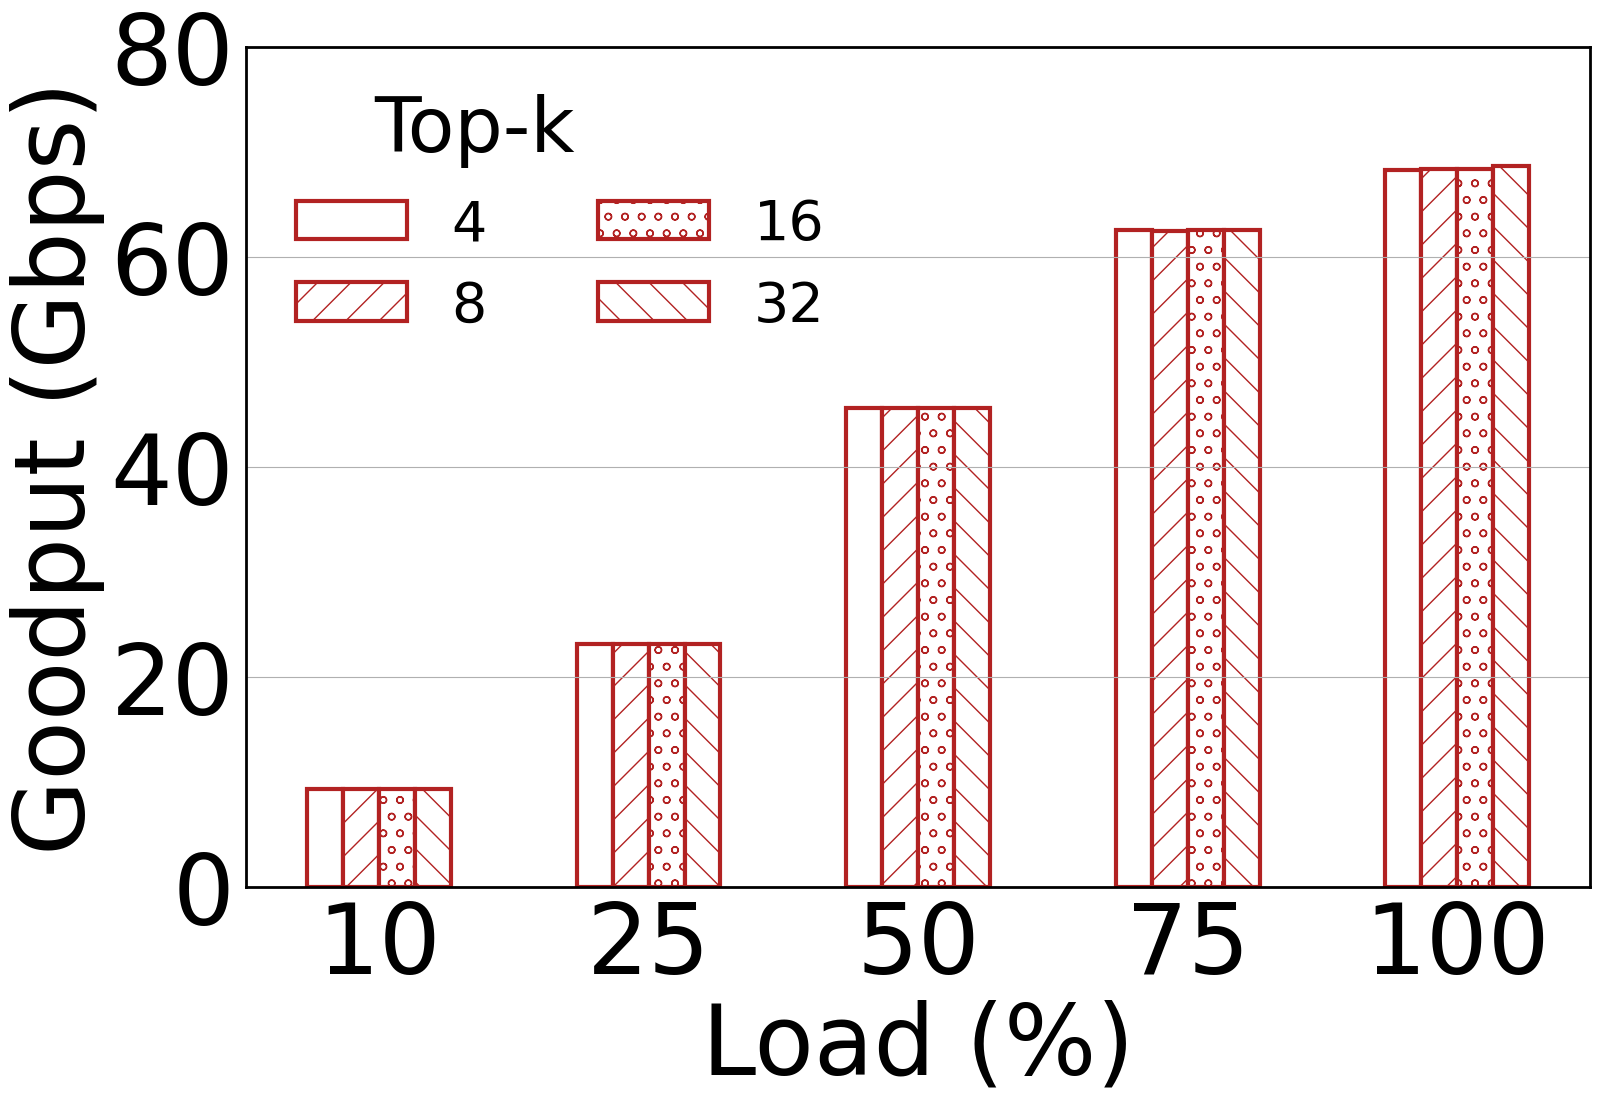

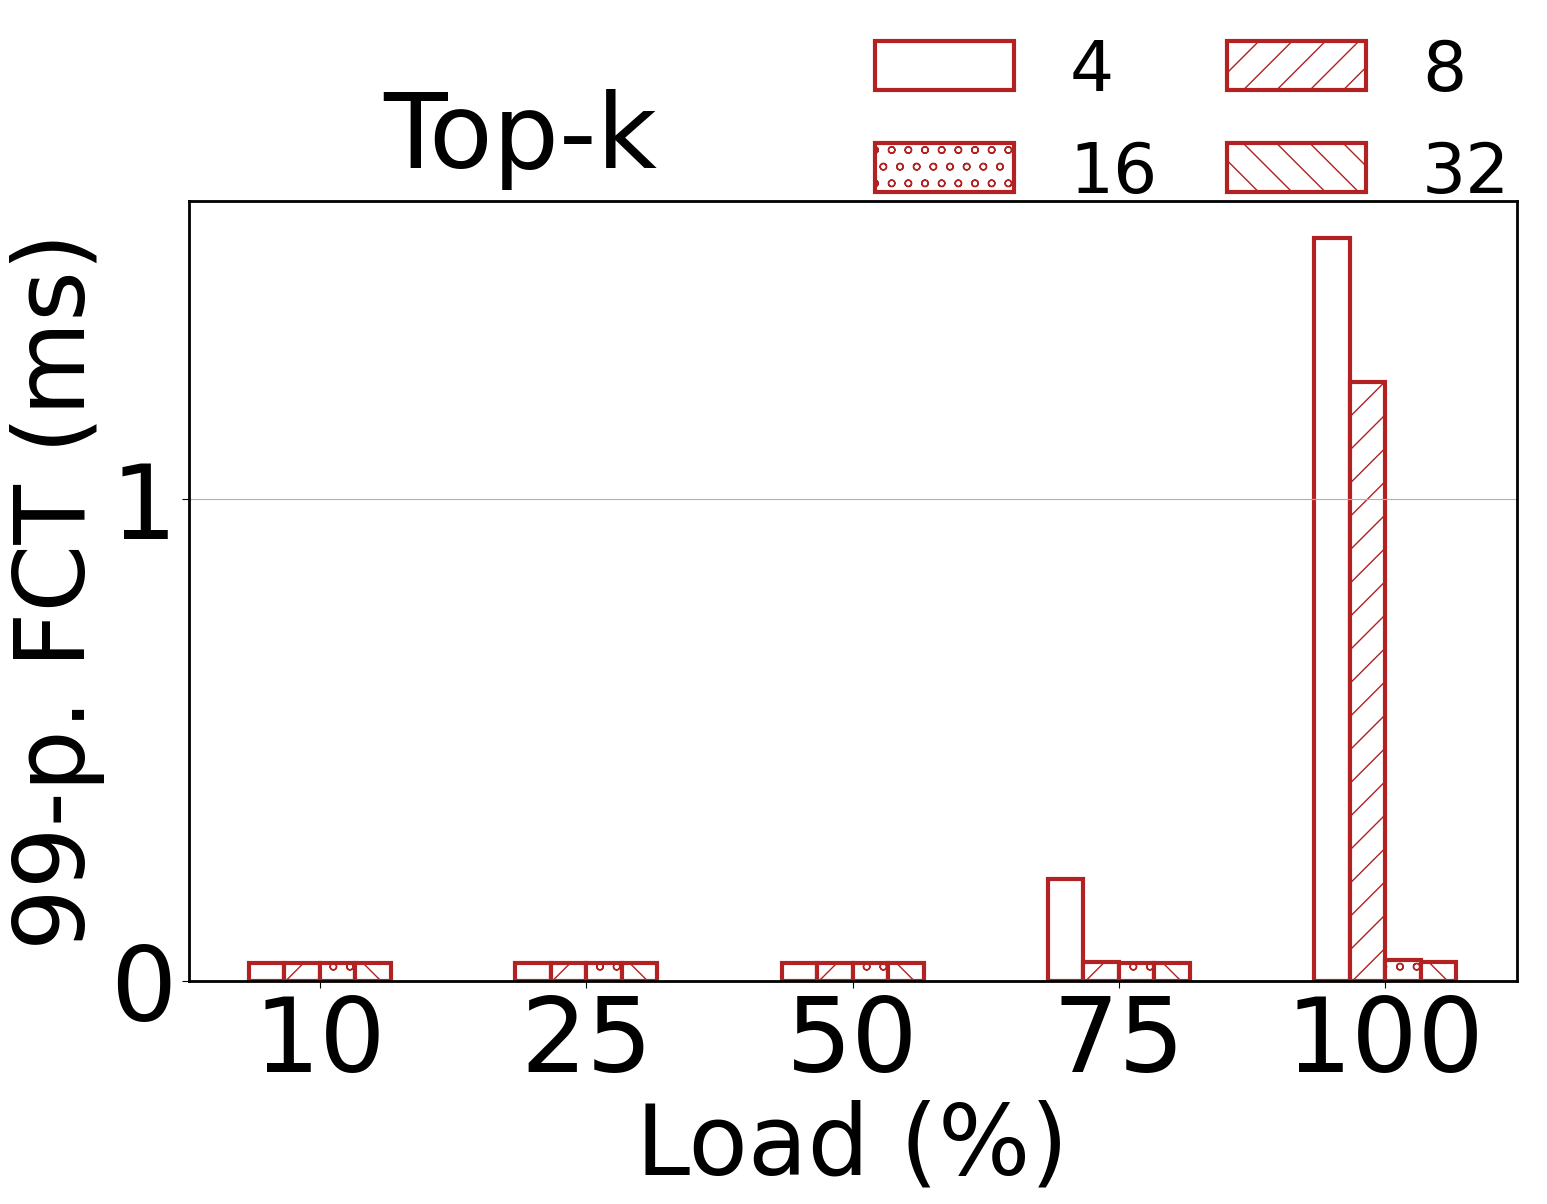

In [21]:
SCHEMES_label = ["4", "8", "16", "32"]
colors = ['white', 'white', 'white', 'white', 'white', 'white', 'white', 'white', 'white']
edge_colors = ['firebrick', 'firebrick', 'firebrick', 'firebrick', 'firebrick', 'firebrick', 'firebrick', 'firebrick', 'firebrick']
hatches = ['', '/', 'o', '\\', 'x', '...', '-', '|', '\\', '。', '\\']
WIDTH = 0.04
my_figsize = [16,12]
my_fontsize = 75
mode = 'multipods'
goodput_bar_plot(labels)
plt.savefig(f"../../FIGS/NSDI25-Figures/One-Pod/2. Top-k-Goodput.pdf")
slowdown_bar_plot("99p", labels, WORKLOADS[0], flow_range='Mice', unit='ms')
plt.savefig(f"../../FIGS/NSDI25-Figures/One-Pod/2. Top-k-FCT.pdf")
